$$
\begin{aligned}
& \text{\textbf{Sets \& Parameters:}} \\
& N \quad \text{(All nodes, 0 = depot)} \\
& C \subset N \quad \text{(Customers)} \\
& K \quad \text{(Vehicles)} \\
& d_{ij} \quad \text{(Distance from } i \text{ to } j \text{, all pairs)} \\
& c_{ij} \quad \text{(Transshipment cost from } i \text{ to } j \text{, customers only)} \\
& q_i \in \mathbb{Z}^+ \quad \text{(Demand of customer } i \in C \text{)} \\
& Q \in \mathbb{Z}^+ \quad \text{(Vehicle capacity)} \\ \\
& \text{\textbf{Decision Variables:}} \\
& x_{ijk} \in \{0,1\} \quad \text{(1 if vehicle } k \text{ travels } i \to j \text{)} \\
& z_{ik} \in \{0,1\} \quad \text{(1 if vehicle } k \text{ directly visits customer } i \text{)} \\
& \text{transfer}_{ijk} \in \{0,1\} \quad \text{(1 if vehicle } k \text{ delivers } i\text{'s demand via } j \text{)} \\
& y_k \in \{0,1\} \quad \text{(1 if vehicle } k \text{ is used)} \\ \\
& \text{\textbf{Objective Function:}} \\
& \min \sum_{k \in K} \sum_{i \in N} \sum_{\substack{j \in N \\ j \neq i}} d_{ij} x_{ijk} + \sum_{k \in K} \sum_{i \in C} \sum_{\substack{j \in C \\ j \neq i}} c_{ij} \, \text{transfer}_{ijk} \\ \\
& \text{\textbf{Constraints:}} \\
& \text{(1) Coverage — served exactly once:} \quad \sum_{k \in K} z_{ik} + \sum_{k \in K} \sum_{\substack{j \in C \\ j \neq i}} \text{transfer}_{ijk} = 1 \quad \forall i \in C \\
& \text{(2) Only visited customer can send:} \quad \text{transfer}_{ijk} \le z_{jk} \quad \forall i, j \in C, \; i \neq j, \; \forall k \in K \\
& \text{(3) Visited customer doesn't receive:} \quad \text{transfer}_{ijk} \le 1 - z_{ik} \quad \forall i, j \in C, \; i \neq j, \; \forall k \in K \\
& \text{(4) Capacity per vehicle:} \quad \sum_{i \in C} q_i z_{ik} + \sum_{i \in C} \sum_{\substack{j \in C \\ j \neq i}} q_i \, \text{transfer}_{ijk} \le Q \, y_k \quad \forall k \in K \\
& \text{(5) Flow conservation:} \quad \sum_{\substack{j \in N \\ j \neq i}} x_{ijk} = \sum_{\substack{j \in N \\ j \neq i}} x_{jik} \quad \forall i \in N, \; \forall k \in K \\
& \text{(6) Depot start:} \quad \sum_{j \in C} x_{0jk} = y_k \quad \forall k \in K \\
& \text{(7) Depot return:} \quad \sum_{i \in C} x_{i0k} = y_k \quad \forall k \in K \\
& \text{(8) Visit link:} \quad z_{ik} = \sum_{\substack{j \in N \\ j \neq i}} x_{jik} \quad \forall i \in C, \; \forall k \in K \\
& \text{(9) Self-loop for circuit:} \quad \text{sl}_{ik} = \begin{cases} 1 - y_k & i = 0 \\ 1 - z_{ik} & i \in C \end{cases} \\
& \text{(10) Binary:} \quad x_{ijk}, \; z_{ik}, \; \text{transfer}_{ijk}, \; y_k \in \{0,1\}
\end{aligned}
$$

In [1]:
import random
random.seed(44)

nodes = {
    0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
    5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
}

C = {i: nodes[i] for i in nodes.keys() if i!=0}

N = list(nodes.keys())

K = list(range(3))
Q = 15

q = {i: random.randint(1,5) for i in C.keys()}

In [3]:
import math
distance = {}
for i in N:
    for j in N:
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [20]:
transship_cost = {}
for i,j in distance.keys():
    if i != j:
        transship_cost[i,j] = distance[(i,j)]*0.9

In [21]:
from ortools.sat.python import cp_model

In [22]:
model = cp_model.CpModel()

In [23]:
z = {
    (i,k): model.NewBoolVar(f"z[{i},{j}]")
    for i in C
    for k in K
}

y = {
    k: model.NewBoolVar(f"y[{k}]")
    for k in K
}

In [24]:
x = {}

for k in K:
    arcs = []
    for i in N:
        for j in N:
            if i != j:
                x[i,j,k] = model.NewBoolVar(f"x[{i},{j},{k}]")
                arcs.append((i,j,x[i,j,k]))
            else:
                if i == 0: #Depot
                    x[0,0,k] = y[k].Not()
                else: 
                    x[i,i,k] = z[i,k].Not()
                    
                arcs.append((i,i,x[i,i,k]))
    model.AddCircuit(arcs)


transfer = {
    (i,j,k): model.NewBoolVar(f"transfer[{i},{j},{k}]")
    for i in C
    for j in C
    for k in K
    if i != j
}

In [25]:
for i in C:
    model.Add(
        sum(z[i,k] for k in K) + sum(transfer[i,j,k] for j in C for k in K if i!=j) == 1
    ) # Coverage, each customer visited or transshipped

In [26]:
for i in C:
    for j in C:
        if i !=j:
            for k in K:
                model.Add(transfer[i,j,k] <= z[j,k]) #only visited customer can send
                model.Add(transfer[i,j,k] <= 1-z[i,k])# visited customer doesn't receive

In [27]:
for k in K:
    model.Add(
        sum(q[i]*z[i,k] for i in C) 
        +  sum(q[i]*transfer[i,j,k] for i in C for j in C if i != j) <= Q*y[k]
    ) #capacity per vehicle (direct + transshipped)

In [28]:
model.Minimize(
    sum(distance[i,j] * x[i,j,k] for i in N for j in N if i != j for k in K)
    + sum(transship_cost[i,j] * transfer[i,j,k] for i in C for j in C if i != j for k in K)
)

In [29]:
solver = cp_model.CpSolver()
status = solver.solve(model)
status

<CpSolverStatus.OPTIMAL: 4>

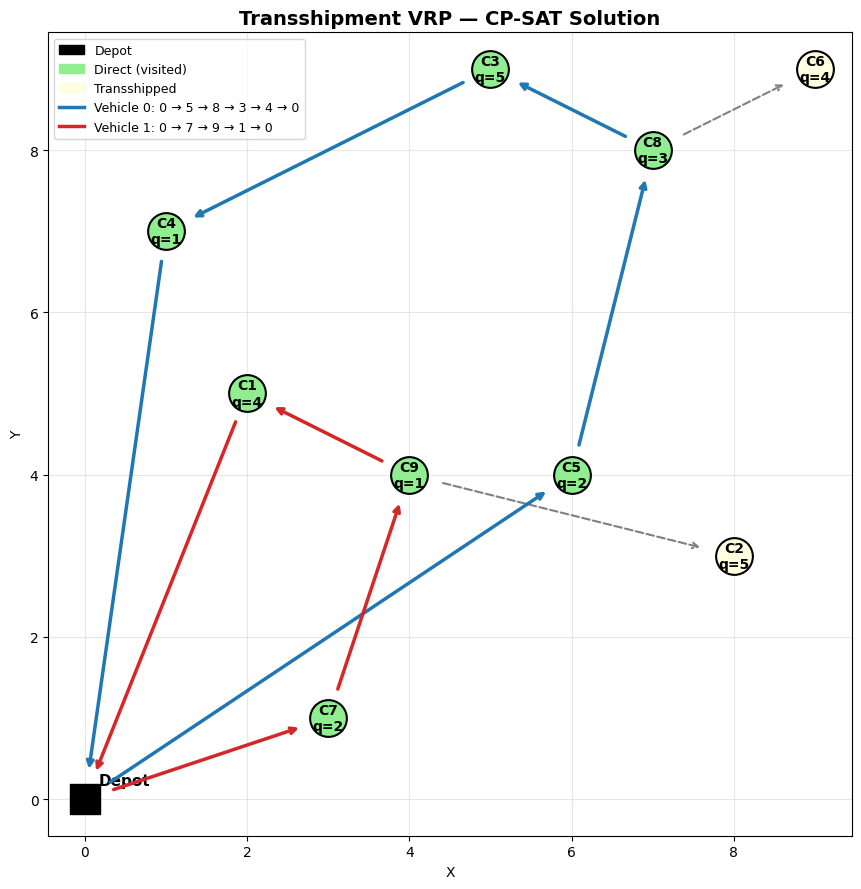

Route cost: 39.0593
Transship cost: 5.7233
Total: 44.7825


In [35]:
# Directly copy-pasted this part from AI

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize(solver, x, z, transfer, y, nodes, C, K, N, q, D=0):
    fig, ax = plt.subplots(figsize=(12, 9))
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple', 'tab:orange']

    # depot
    ax.scatter(*nodes[D], c='black', s=450, marker='s', zorder=5)
    ax.annotate('Depot', nodes[D], fontsize=11, fontweight='bold',
                xytext=(10, 10), textcoords='offset points')

    # customers
    for i in C:
        direct = any(solver.Value(z[i,k]) == 1 for k in K)
        color = 'lightgreen' if direct else 'lightyellow'
        ax.scatter(*nodes[i], c=color, s=700, zorder=4,
                   edgecolors='black', linewidths=1.5)
        ax.annotate(f'C{i}\nq={q[i]}', nodes[i], fontsize=10, fontweight='bold',
                    ha='center', va='center', zorder=6)

    # routes
    for k in K:
        if solver.Value(y[k]) == 0:
            continue
        color = colors[k % len(colors)]

        route = [D]
        cur = D
        while True:
            nxt = next((j for j in N if j != cur and solver.Value(x[cur,j,k]) == 1), None)
            if nxt is None or nxt == D:
                route.append(D); break
            route.append(nxt); cur = nxt

        for a, b in zip(route[:-1], route[1:]):
            ax.annotate('', xy=nodes[b], xytext=nodes[a],
                        arrowprops=dict(arrowstyle='->', color=color, lw=2.5,
                                        shrinkA=22, shrinkB=22), zorder=3)

        route_str = ' → '.join(map(str, route))
        ax.plot([], [], color=color, lw=2.5, label=f'Vehicle {k}: {route_str}')

    # transshipment arrows (dashed)
    for i in C:
        for j in C:
            if i == j: continue
            for k in K:
                if solver.Value(transfer[i,j,k]) == 1:
                    ax.annotate('', xy=nodes[i], xytext=nodes[j],
                                arrowprops=dict(arrowstyle='->', color='gray',
                                                lw=1.5, linestyle='--',
                                                shrinkA=25, shrinkB=25), zorder=2)

    # legend
    depot_p = mpatches.Patch(color='black', label='Depot')
    direct_p = mpatches.Patch(color='lightgreen', label='Direct (visited)')
    trans_p  = mpatches.Patch(color='lightyellow', label='Transshipped')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=[depot_p, direct_p, trans_p] + handles,
              loc='upper left', fontsize=9)

    ax.set_title('Transshipment VRP — CP-SAT Solution', fontsize=14, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')
    plt.tight_layout(); plt.show()

visualize(solver, x, z, transfer, y, nodes, C, K, N, q, D=0)
route_cost = sum(distance[i,j] * solver.Value(x[i,j,k])
                 for i in N for j in N if i != j for k in K)
trans_cost = sum(transship_cost[i,j] * solver.Value(transfer[i,j,k])
                 for i in C for j in C if i != j for k in K)
print(f"Route cost: {route_cost:.4f}")
print(f"Transship cost: {trans_cost:.4f}")
print(f"Total: {route_cost + trans_cost:.4f}")